In [2]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import numpy as np
import pickle

from flonacomldft.utils.io_utils import load_pickle_file, load_csv_file, get_project_path
from flonacomldft.sampling import run_metropolis
from flonacomldft.utils.diagnostics import get_ESS
from flonacomldft.models.mixture import Mixture, get_models
from flonacomldft.internal_coordinates import Coordinates_mapping, join_data

# from flonacomldft.train_flow_from_data import get_ratio_acc
from flonacomldft.free_energy_computations import (
    compute_TFP_logratio, compute_deepBAR_logratio,
    compute_TFP, compute_BAR
)

from ase.units import kB

/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
coord_mapping = Coordinates_mapping()
T = 300

/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  new_frame = data.loc[atoms, set(new_cols) - set(self.columns)]
/mnt/home/amolina/miniconda3/envs/ml-dft/lib/python3.10/site-packages/chemcoord/_generic_classes/generic_core.py:51

In [21]:
project_path = "/mnt/home/amolina/ceph/ADAPTIVE-DFT/2-multimodal-sampling/results_2/"
folder = "results_multimodal_sampling_mixture_25346510/mixture_mcmc_dic_25346510.pkl"

### 1.a Computing the Rhat convergence criteria

In [22]:
import arviz as az
from arviz.utils import get_coords, _var_names

In [23]:
dict_results_mh = load_pickle_file(folder, project_path)
xs_np = dict_results_mh["xs"].detach().numpy()
xs_np = xs_np.transpose(1, 0, 2)

burn_in = 100

idata = az.convert_to_inference_data(xs_np[:, burn_in:, :])
coords = {}
data = get_coords(az.convert_to_dataset(idata, group="posterior"), coords)
var_names = None
filter_vars = None

var_names = _var_names(var_names, data, filter_vars)
n_draws = data.dims["draw"]
n_samples = n_draws * data.dims["chain"]
first_draw = data.draw.values[0] # int of where where things should start
labels = ['x{:d}'.format(i) for i in range(12)]

In [24]:
data

<xarray.Dataset>
Dimensions:  (chain: 50, draw: 250, x_dim_0: 12)
Coordinates:
  * chain    (chain) int64 0 1 2 3 4 5 6 7 8 9 ... 40 41 42 43 44 45 46 47 48 49
  * draw     (draw) int64 0 1 2 3 4 5 6 7 8 ... 242 243 244 245 246 247 248 249
  * x_dim_0  (x_dim_0) int64 0 1 2 3 4 5 6 7 8 9 10 11
Data variables:
    x        (chain, draw, x_dim_0) float32 0.06326 -0.07882 ... -0.1845 0.2514
Attributes:
    created_at:     2023-08-07T14:59:46.484139
    arviz_version:  0.16.1

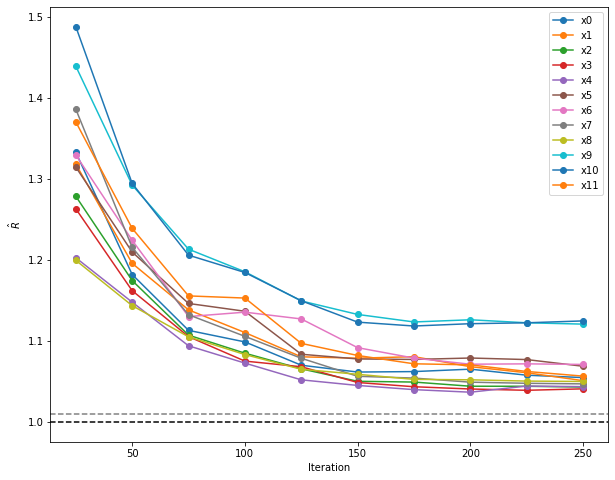

In [25]:
## Compute where to split the data to diagnostic the convergence
n_split = 10
xdata = np.linspace(n_samples / n_split, n_samples, n_split)
draw_divisions = np.linspace(n_draws // n_split, n_draws, n_split, dtype=int)

rhat_s = np.stack([np.array(az.rhat(data.sel(draw=slice(first_draw + draw_div)),
                    var_names=var_names,
                    method="rank",
                )['x'])
        for draw_div in draw_divisions
        ])

plt.figure(figsize=(10, 8))
plt.plot(draw_divisions, rhat_s, '-o',  label=labels)
plt.axhline(1, c='k', ls='--')
plt.axhline(1.01, c='grey', ls='--')
plt.xlabel('Iteration')
plt.ylabel(r'$\hat{R}$')
plt.legend()